In [12]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import nilearn.plotting as plotting
import nitools as nt
import nibabel as nb
import OptimalBattery.estimate as es
import OptimalBattery.construct as ct


# define atlas and dirs

In [13]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

In [14]:
  # Load surface files for left and right hemispheres
surfs = [f"{func_fus_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig

In [15]:
# Load glasser atlas
# roi (prefrontal cortex)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'
glasser_atlas = atlas.read_data([model_name_L,model_name_R])


In [16]:
# define PFC parcel and get the indices of the PFC parcels
PFC_parcels = ['OFC', '10pp', '10r', '8C', 's6-8', '25', 'p24', 'p47r', '46', 'a10p',
                          '10d', '9m', '8Av', 'IFJp', '10v', '13l', '45', 'i6-8', 
                          '9-46d', 'IFJa', '47s', 'SFL', 'a24', 'IFSp', '47m', 
                          '9p', '9a', 'pOFC', '8Ad', '11l', 'IFSa', 'a9-46v', 
                          '44', 'a47r', '55b', '47l', 's32', 'p9-46v',
                            '8BM', 'p10p', '8BL', 'p32', 'a32pr', 'd32']    # PNAS paper



# Load the GIFTI file
gifti_data = nb.load(model_name_L)
parcel_names = [label.label for label in gifti_data.labeltable.labels]
parcel_names = [name[len("L_"):] if name.startswith("L_") else name for name in parcel_names]
parcel_names = [name[:-len("_ROI")] if name.endswith("_ROI") else name for name in parcel_names]

# Get the indices of the PFC parcels
ROI_cortex = []
for name in PFC_parcels:
    ROI_cortex.append(parcel_names.index(name))


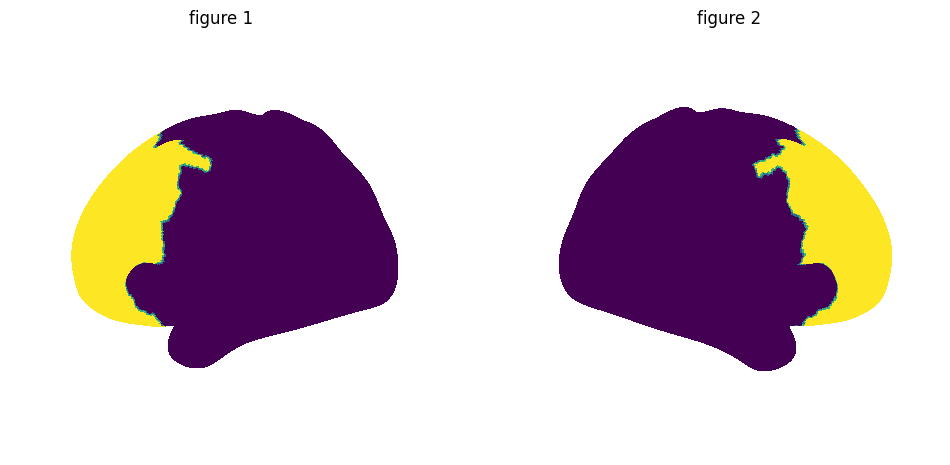

12094

In [17]:
# make mask for PFC and plot 
ROI_mask = (np.isin(glasser_atlas, ROI_cortex)).astype(int)
mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.0, cmap='viridis', figsize=(12, 6))
plt.show()

# find indices where mask is 1 
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

# Load data

In [18]:
subj_list = ['sub-02']

In [19]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/Social')


data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-social',type='CondRun',subj=subj_list)
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-social',type='CondAll',subj=subj_list)
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]

data_mdtb_s1_half,info_mdtb_1_half  =MDTB_dataset.get_data(space=space,ses_id='ses-social',type='CondHalf',subj=subj_list)
data_mdtb_s1_half[np.isnan(data_mdtb_s1_half)] = 0
data_mdtb_s1_half = data_mdtb_s1_half[:,:,:]


recenter data around rest so that the variance in the Glibrary is signal compared to rest  
centers each row around the rest in its run and remove the rest row from each run


In [20]:
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='task_name',center_condition='rest')
data_mdtb_s1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='task_name',center_condition='rest')
print(data_mdtb_s1_run.shape)
print(data_mdtb_s1_all.shape)

(1, 184, 59518)
(1, 23, 59518)


In [21]:
half_1_indices = np.where(info_mdtb_1_run['half'] == 1)[0]
data_train = data_mdtb_s1_run[:,half_1_indices,:]
data_train_info = info_mdtb_1_run.iloc[half_1_indices]


In [22]:
half_2_indices = np.where(info_mdtb_1_run['half'] == 2)[0]
data_test = data_mdtb_s1_run[:,half_2_indices,:]
data_test_info = info_mdtb_1_run.iloc[half_2_indices]


# Define mask used for top parcel identification, Glibrary estimation and evaluation of predicition error

# Get crossvalidated second moment matrix (GLib)

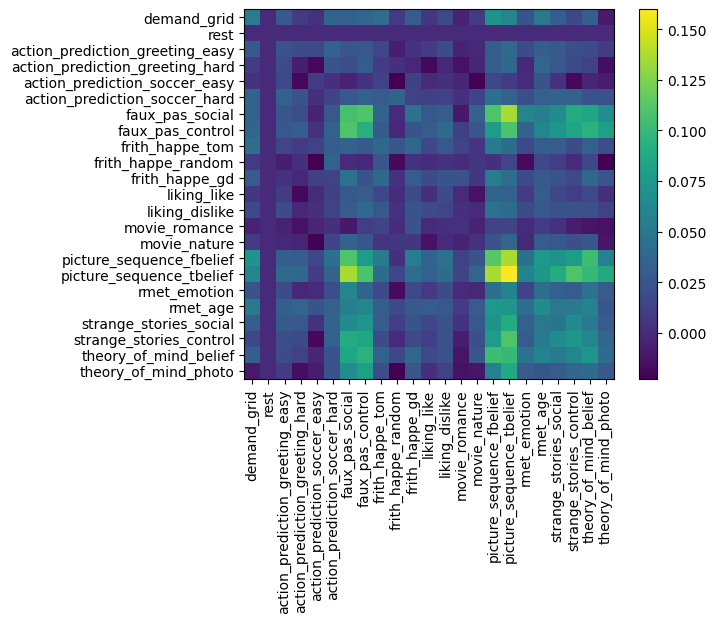

In [23]:
cond_vec = np.tile(np.arange(1, 23 + 1), 4)
part_vec = np.repeat(np.arange(1, 4 + 1), 23)
Gs_list = []
E_list = []
for i in range(data_train.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_train[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

task_names = info_mdtb_1_all['task_name'].unique()

plt.imshow(G_Lib)
plt.colorbar()
plt.xticks(np.arange(len(task_names)), task_names, rotation=90)
plt.yticks(np.arange(len(task_names)), task_names)
plt.show()


# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [24]:
# make data pt tensor
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
data_train_all = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
data_test = pt.tensor(data_test, dtype=pt.float32, device=device)
data_train = pt.tensor(data_train, dtype=pt.float32, device=device)

ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)
parcelation = pt.tensor(glasser_atlas, dtype=pt.float32, device=device)

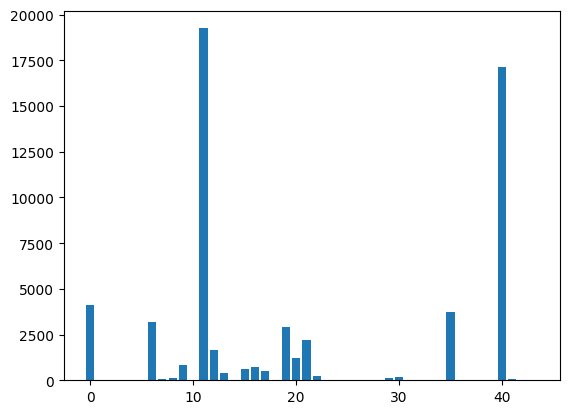

In [25]:
full_vs_train = es.estimate_Vs(data_train_all,parcellation=parcelation,ROI_mask= ROI_mask)
full_vs_test = es.estimate_Vs(data_test,parcellation=parcelation,ROI_mask=ROI_mask)

# Get list of parcels ordered by size by counting voxel assignments across subjects
Us = es.estimate_Us(data_train_all, full_vs_train,method='correlation',hard=True)
parcel_counts = Us.sum(dim=(0,2))
sorted_parcels = pt.argsort(parcel_counts, descending=True).cpu().numpy()
parcel_counts = parcel_counts.cpu().numpy()
total_parcels = len(sorted_parcels)

plt.bar(range(len(parcel_counts)), parcel_counts)
plt.show()

In [26]:
def get_condition_indices(df):
    """
    Get condition indices from a dataframe and record the duration of each condition
    Parameters:
        df(pd.DataFrame): dataframe containing condition indices needs to include:
            - 'cond_name': name of the condition
            - 'run': run number
            - 'task_name': name of the task
    Returns:
        condition_indices(np.ndarray): condition indices
    """
    unique_conditions = df['task_name'].unique()
    new_df = pd.DataFrame(columns=['task_name', 'indices', 'duration'])
    
    # Filter only the first run
    first_run_df = df[df['run'] == df['run'].min()]
    task_run_counts = first_run_df.groupby('task_name')['task_name'].nunique()
    duration_map = {1: 30, 2: 15, 3: 10}
    
    # Populate the new dataframe
    for condition in unique_conditions:
        indices = df[df['task_name'] == condition].index.tolist()
        
        # Identify task_name for the condition from the original dataframe
        task_name = df[df['task_name'] == condition]['task_name'].values[0]
        num_conditions = task_run_counts.get(task_name, 1)
        duration = duration_map.get(num_conditions, 30)
        
        new_row = {'task_name': condition, 'indices': indices, 'duration': duration}
        new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)
    
    return new_df

In [27]:
condition_df= get_condition_indices(data_train_info)

In [29]:
battery_sizes = [3,4,5,6,7,8,10]
# parcel_sizes = [2,4,6,8,10,16,total_parcels]

parcel_sizes = [10,total_parcels]
# battery_sizes = [4,6]


In [30]:
results_df = pd.DataFrame()
for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    parcel_indices = sorted_parcels[:n_parcel]
    VLib = full_vs_train[:,parcel_indices]
    Vtest = full_vs_test[:,parcel_indices]
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")
        # Generate possible battery combinations for current battery size and calculate eigenmetrics
        D = ct.build_combinations(G_Lib, strategy='random',n_batteries=10000,n_tasks=n_task,seed=1,replacement=False,rest_idx=1)
        D_ev = ev.evluate_dataframe( D = D, condition_df= condition_df, YLib= data_train,
                                     VLib= VLib, Ytest= data_test, Vtest= Vtest,indices=ROI_indices,localizer_time=7)

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    
    


Processing parcel size: 10
Processing battery size: 3
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing combination: 1000
Processing battery size: 5
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing battery size: 6
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing battery size: 7
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000
Processing battery size: 8
Processing com

In [158]:
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cortex-full_MDTB_ses-01_ses-02_results.tsv')

# save to tsv
# results_df.to_csv(name, sep="\t", index=False)

#load
# results_df = pd.read_csv(name, sep="\t")

# Make proposal sets (sampling with repelcament from the batteries evaluated) for each n_tasks and n_parcels

In [159]:
n_proposal_sets = 100
metrics = ["variance", "variance_mc", "log_det_mc"] # Metrics to evaluate


# Get unique values of n_parcel and n_task from the results dataframe
unique_n_parcel = results_df["n_parcel"].unique()
unique_n_task = results_df["n_task"].unique()



In [160]:
proposals_list = []
for n_parcel in unique_n_parcel:
    print(f"Processing parcel size: {n_parcel}")
    for n_task in unique_n_task:
        print(f"Processing battery size: {n_task}")
        subset_df = results_df[(results_df["n_parcel"] == n_parcel) & (results_df["n_task"] == n_task)]
        
        for iter in range(n_proposal_sets):
            sampled_df = subset_df.sample(len(subset_df), replace=True)
            
            for metric in metrics:
                best_row = sampled_df.loc[sampled_df[metric].idxmax()]
                # if the same top battery is proposed multiple times, only keep the first instance
                if isinstance(best_row, pd.DataFrame):
                    best_row = best_row.iloc[0]
                
                cos_subjects = best_row["cos_subjects"]
                proposals_list.append({
                    "n_iter": iter,
                    "n_parcel": n_parcel,
                    "n_task": n_task,
                    "metric": metric,
                    "cos_subjects": cos_subjects,
                })


iter_df = pd.DataFrame(proposals_list)

Processing parcel size: 6
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14
Processing parcel size: 16
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14
Processing parcel size: 44
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14


# seperate the list of prediction errors of all subjects into values for each subject for the top battery by each metric in each iteration for each n_tasks and n_parcels

after seperating

In [161]:
expanded_results = []
for _, row in iter_df.iterrows():
    if isinstance(row["cos_subjects"], str):
        row["cos_subjects"] = eval(row["cos_subjects"])
    row_cos_values = row["cos_subjects"]
    for i,subj_cos in enumerate(row_cos_values):
        cos_value = row_cos_values[i]
        expanded_results.append({
            "n_iter": row["n_iter"],
            "n_parcel": row["n_parcel"],
            "n_task": row["n_task"],
            "metric": row["metric"],
            "subject": i+1,
            "cos_value": cos_value
        })
# this is just expanded version of the iter_df
expanded_results_df = pd.DataFrame(expanded_results)

# this averages the results for each subject across all iterations
averaged_results_df = (
    expanded_results_df
    .groupby(["n_parcel", "n_task", "metric", "subject"], as_index=False)
    .agg({"cos_value": "mean"})
)

# Aggregate across subjects to get mean and SEM
aggregated_results_df = averaged_results_df.groupby(["n_parcel", "n_task", "metric"], as_index=False).agg(
    cos_mean=("cos_value", "mean"),
    cos_sem=("cos_value", lambda x: x.std() / np.sqrt(len(x)))  # SEM
)

# make a df for the baseline battery

In [162]:
baseline_df = results_df.copy()
if isinstance(baseline_df["cos_subjects"].iloc[0], str):
    baseline_df["cos_subjects"] = baseline_df["cos_subjects"].apply(eval)
baseline_df = baseline_df.explode("cos_subjects")  
baseline_df["cos_subjects"] = baseline_df["cos_subjects"].astype(float)

baseline_aggregated_df = baseline_df.groupby(["n_parcel", "n_task"], as_index=False).agg(
    cos_mean=("cos_subjects", "mean")
)

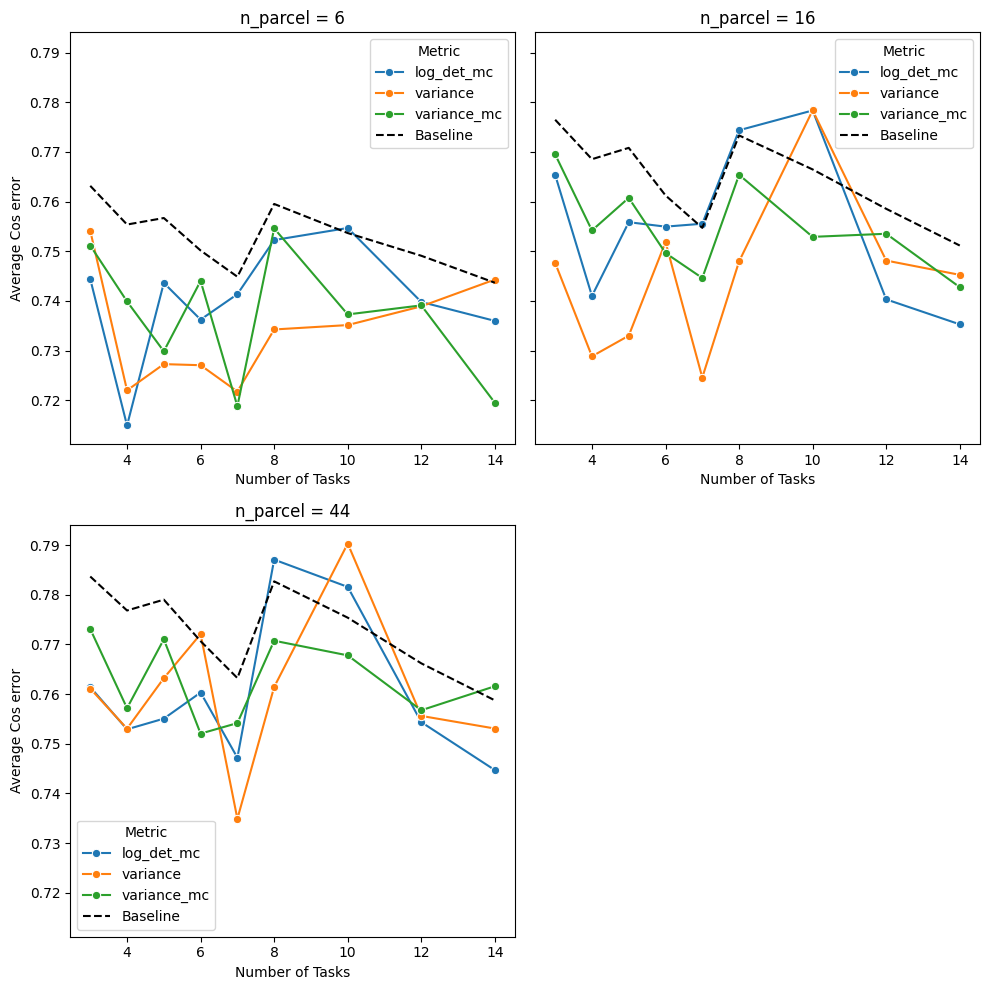

In [163]:
num_plots = len(unique_n_parcel)
n_cols = int(np.ceil(np.sqrt(num_plots))) 
n_rows = int(np.ceil(num_plots / n_cols)) 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), sharex=False, sharey=True)
axes = np.array(axes).flatten()

for ax, n_parcel in zip(axes, unique_n_parcel):
    df_plot = aggregated_results_df[aggregated_results_df["n_parcel"] == n_parcel]
    sns.lineplot(
        data=df_plot, x="n_task", y="cos_mean", hue="metric", ax=ax, marker="o"
    )

    for metric in df_plot["metric"].unique():
        metric_data = df_plot[df_plot["metric"] == metric]
        ax.fill_between(metric_data["n_task"],
                        metric_data["cos_mean"] - metric_data["cos_sem"],
                        metric_data["cos_mean"] + metric_data["cos_sem"],
                        alpha=0.2)

    # Plot the baseline for this n_parcel
    baseline_data = baseline_aggregated_df[baseline_aggregated_df["n_parcel"] == n_parcel]
    sns.lineplot(
        data=baseline_data, x="n_task", y="cos_mean", ax=ax, color="black", linestyle="dashed", label="Baseline"
    )
    ax.set_title(f"n_parcel = {n_parcel}")
    ax.set_xlabel("Number of Tasks")
    ax.set_ylabel("Average Cos error")
    ax.legend(title="Metric")

# Hide unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()



In [141]:
D = ct.build_combinations(G_Lib, strategy='random',n_batteries=100000,n_tasks=5,seed=1,replacement=False,rest_idx=1)
len(D)


7315

In [149]:
# find row with the highest log_det_mc
best_row = D.loc[D['variance'].idxmax()]
combination = best_row['combination']
print(combination)


(6, 7, 15, 16, 1)


In [150]:
import OptimalBattery.estimate as et
n_parcel = 8
combination = list(combination)

regressor_list = ct.build_combination_regressors(combination,condition_df,8)
print(regressor_list)
YLib_subset = ct.average_regressors(data_train,regressor_list)
YLib_subset = ut.center_matrix(YLib_subset, axis=1)
YLib_subset = ut.normalize_matrix(YLib_subset, axis=1)

parcel_indices = sorted_parcels[:n_parcel]
VLib = full_vs_train[:,parcel_indices]
Vtest = full_vs_test[:,parcel_indices]

# get the Vs for the combination
VLib_subset = VLib[combination, :]
VLib_subset = ut.center_matrix(VLib_subset, axis=0)
VLib_subset = ut.normalize_matrix(VLib_subset, axis=0)


Ytest = data_test
Ytest = ut.center_matrix(Ytest, axis=1)
Ytest = ut.normalize_matrix(Ytest, axis=1)

Vtest = full_vs_test[:,parcel_indices]
Vtest = ut.center_matrix(Vtest, axis=0)
Vtest = ut.normalize_matrix(Vtest, axis=0)

U_hats = et.estimate_Us(YLib_subset, VLib_subset,method='correlation',hard=True)
cos_subs, cos_mean = ev.get_prediction_error(Ytest, Vtest, U_hats, indices=ROI_indices)
cos_mean

[[52, 29, 6], [53, 76, 7], [61, 38, 84], [85, 39, 62], [1, 70, 47]]


tensor(0.7202, device='cuda:0')